# Fit one object

In [1]:
from AllModelFunctions import *
import sys
sys.path.append('/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject')
from functions import import_spectra


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline
from PyAstronomy import pyasl
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from datetime import date

### Parameters

In [2]:
object_name = 'Vela X-1'
object_ = object_name_to_save_name(object_name)

galaxy = 'Milkyway'
vsini_best = 110

today = date.today()
save_path = f"/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject/Plots/{object_}/"
lines_path = f"/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject/ModelFitting/Lines/{object_}/"

### Import spectra & models

In [3]:
spectra = import_spectra(object_)
models = import_models_quickload(galaxy)

#### Calculate log(g)

In [4]:
# # Calculate log(g)[cgs]
# df_AllParams = pd.read_csv("/mnt/c/Users/luukv/Documenten/NatuurSterrkenkundeMasterProject/CodeMP/MasterProject/tables/results/ALLPARAMETERS.csv")
# df_AllParams['logg'] = (np.log10(df_AllParams.Mopt * M_sun.value * G.value * 100 ** 3 / (df_AllParams.Ropt * R_sun.value * 100)**2))
# logg = round(df_AllParams[['id', 'logg']].loc[df_AllParams['id'] == object_name]['logg'].reset_index(drop=True).at[0], 1)

# # Filter models around log(g)
# models = models_in_interval(models, T1=0, T2=100000, log_g1=logg-0.2, log_g2=logg+0.2)

### Determine radial velocity of the object

The velocity of the object is: -19.205790239773457 +- 6.096130708792711


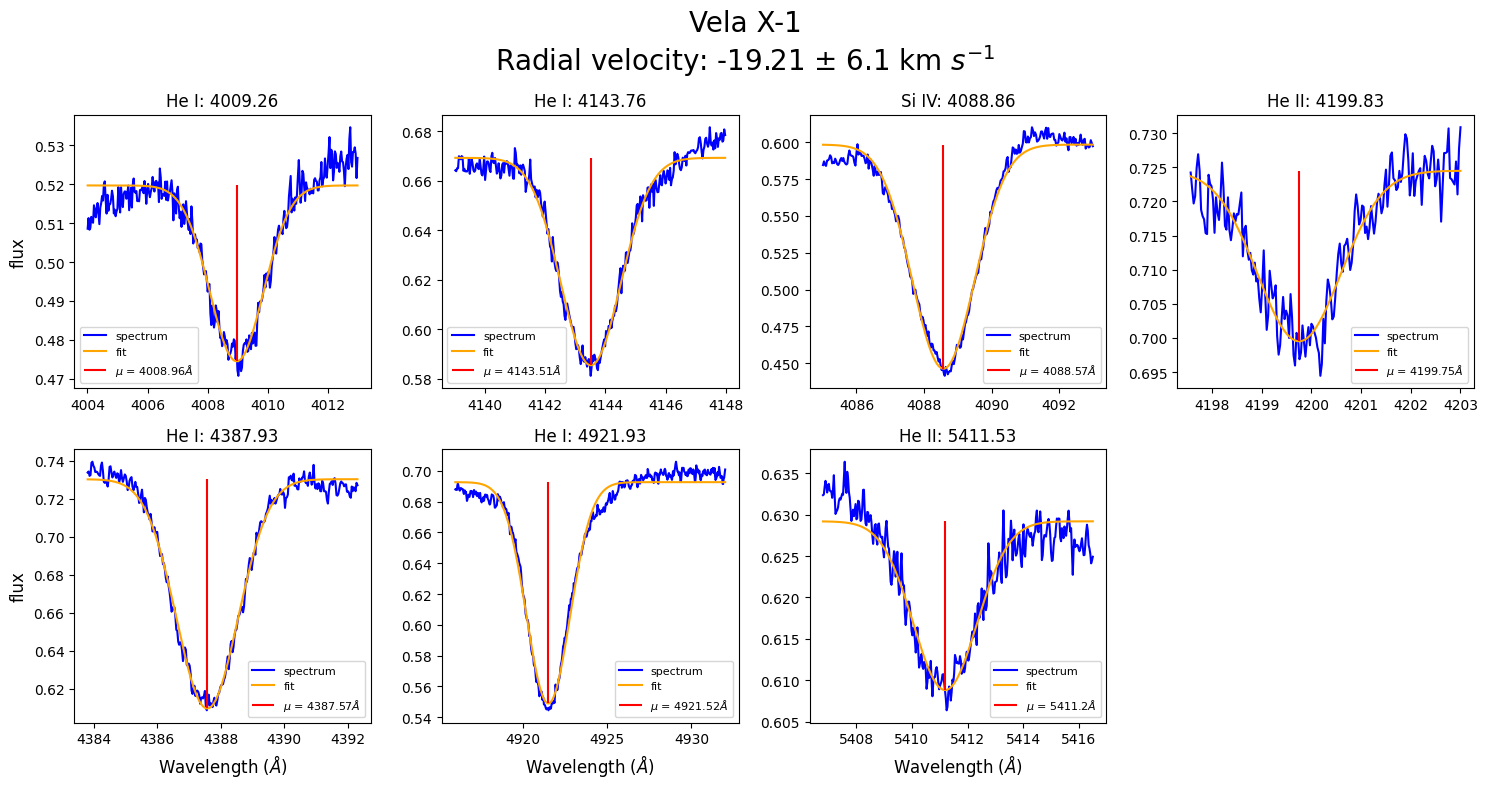

The radial velocities are:
[-22.18451408893148, -17.745949463000255, -21.101482276753885, -5.58335887785935, -24.39245005357379, -24.915122982068645, -18.51765393622679]


In [5]:
spectral_lines_doppler = lines_doppler(object_name)
vrad = determine_radial_velocity(spectra, spectral_lines_doppler, gaussian, object_name,
                                              save=(save_path + f'({today})RadialVelocity.png'))

### Do the grid search

In [6]:
spectral_lines_model_fit = lines_model_fit(object_name)
SNR = SignalToNoise(object_name)
chi2, chi2_perline = chi_squared_for_all_models(spectra, models, lines_path, SNR=SNR, vrad=vrad, vsini=vsini_best)

THIS IS THE NEW FUNCTION
DONE


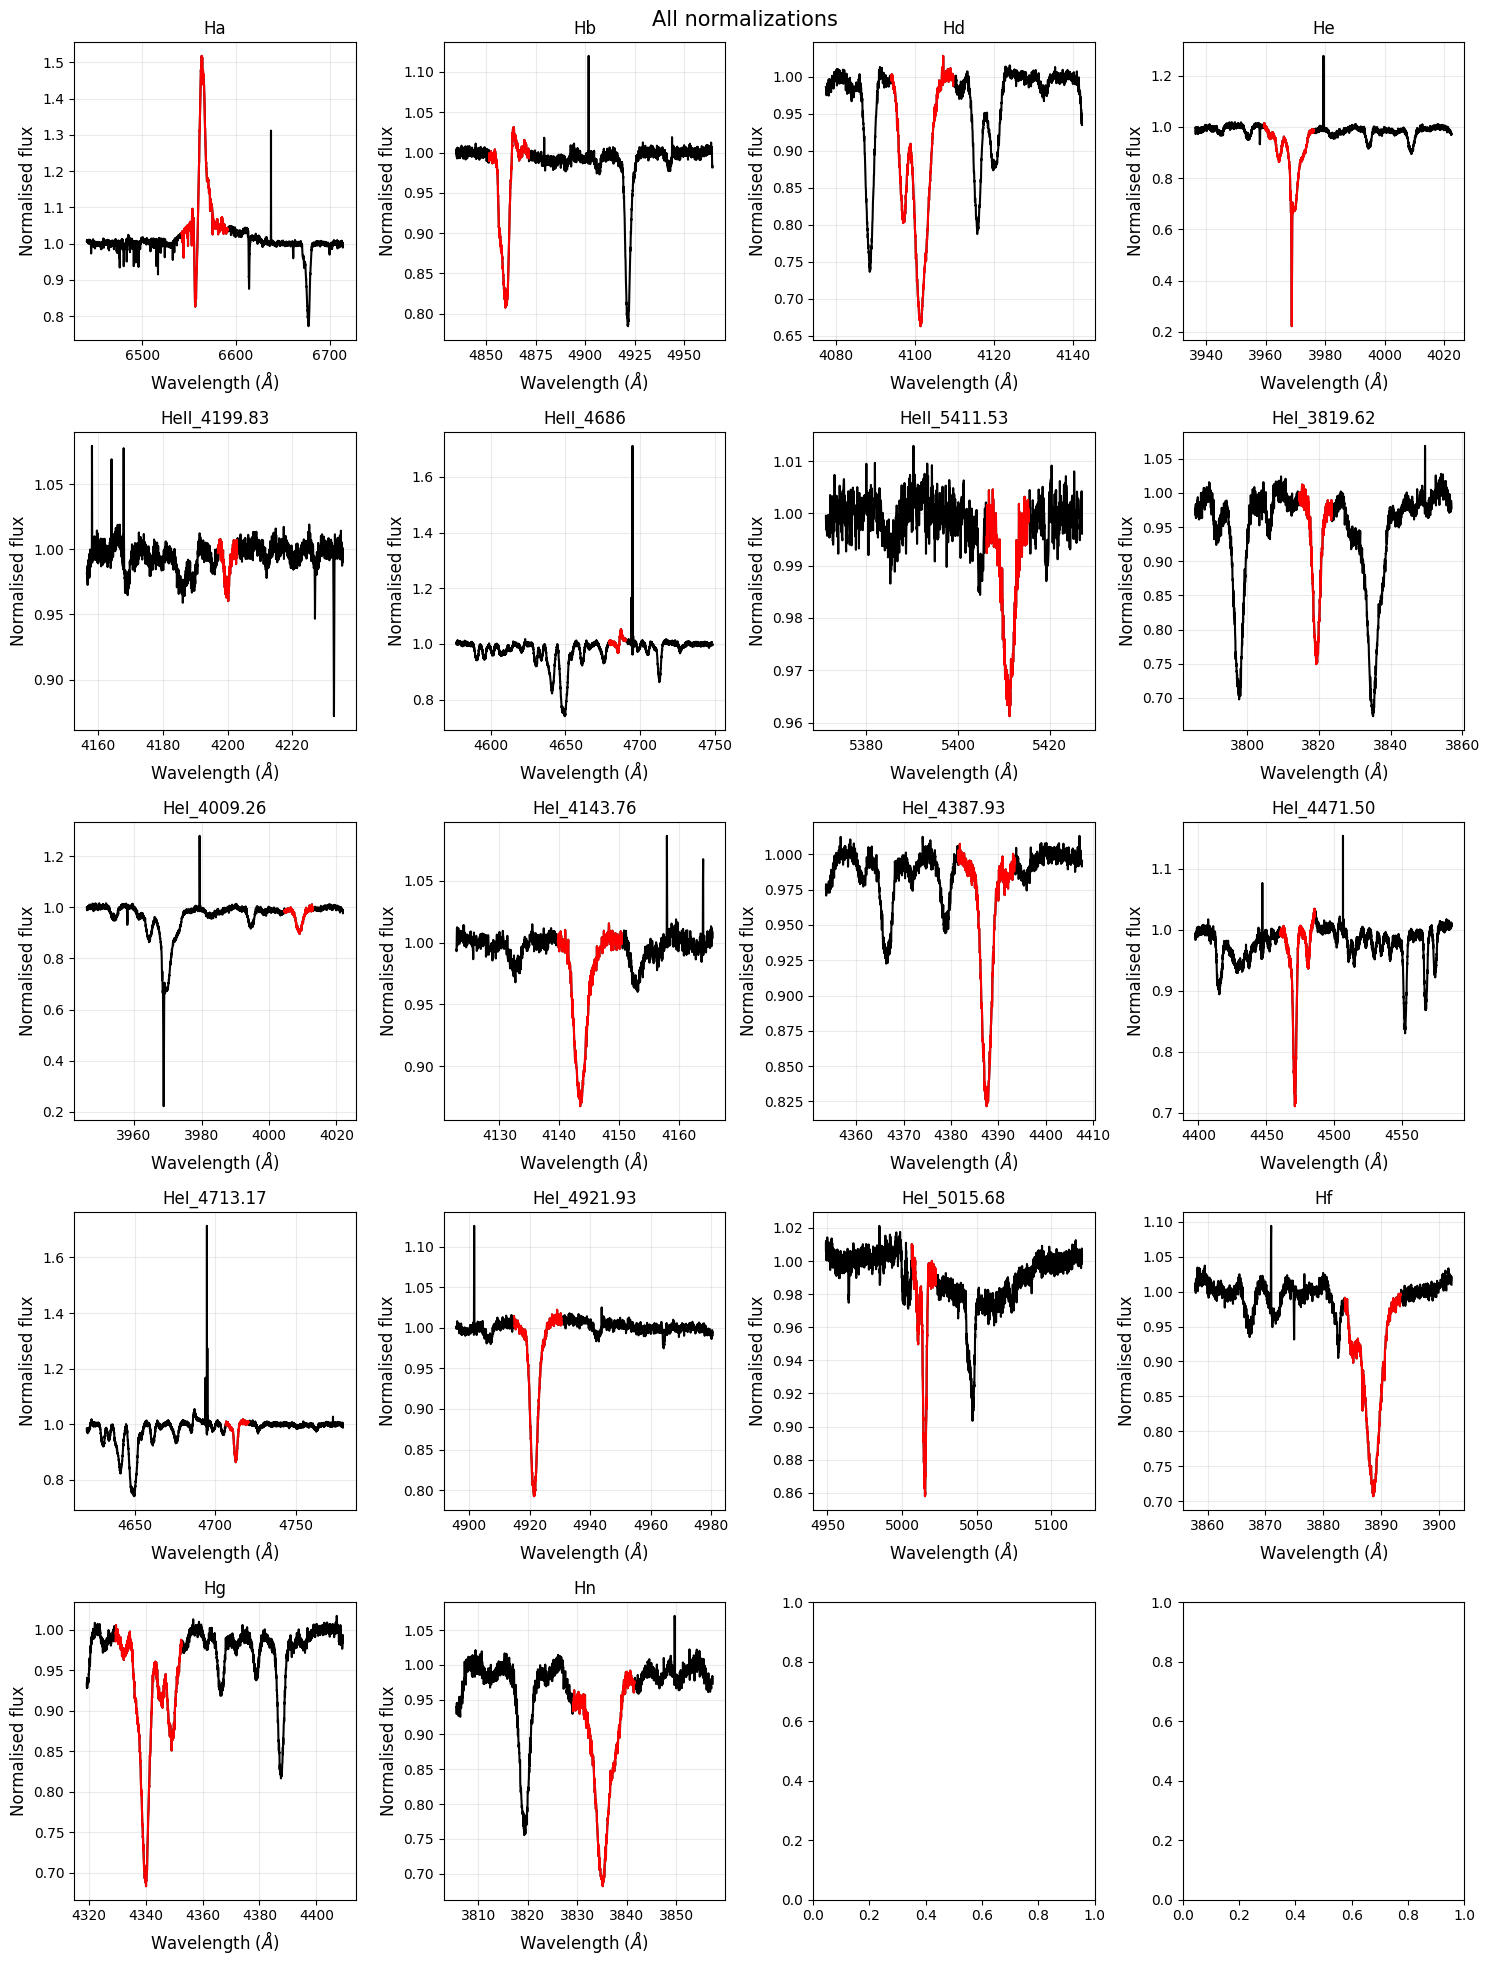

In [7]:
def plot_normalize_lines(spectra, lines):
    """
    Plot the normalization of the spectral lines.
    The lines are normalized with a linear with to the 
    predetermined continuum.

    Args:
        spectra (dict): UVES spectra
        lines (dict): Ranges of the spectral lines
    """
    # Read in all line data
    lines = []
    spectra = []
    # Get the list of folders in the directory
    folders = [os.path.join(lines_path, f) for f in os.listdir(lines_path) if os.path.isdir(os.path.join(lines_path, f))]
    line_labels = [f for f in os.listdir(lines_path) if os.path.isdir(os.path.join(lines_path, f))]
    for line_label, path in zip(line_labels, folders):
        # Get Line data
        with open(path + '/Line.json', 'r') as file:
            data = json.load(file)
        # SAVE LINE
        lines.append(data)

        # Get Line data
        with open(path + '/Spectrum.json', 'r') as file:
            data = json.load(file)
        # SAVE LINE
        spectra.append(data)


    num_plots = len(lines)
    num_rows = (num_plots - 1) // 4 + 1  # Calculate the number of rows needed

    fig, axes = plt.subplots(num_rows, 4, figsize=(15, num_rows * 4))

    # Flatten axes if necessary
    if num_rows == 1:
        axes = [axes]

    for i, ax_row in enumerate(axes):

        for j, ax in enumerate(ax_row):
            plot_index = i * 4 + j

            if plot_index < num_plots:
                wav_line, flux_line = lines[plot_index]['Wavelength'], lines[plot_index]['Flux']
                wav, flux = spectra[plot_index]['Wavelength'], spectra[plot_index]['Flux']

                ax.plot(wav, flux, color='black', alpha=1)
                ax.plot(wav_line, flux_line, color='red', alpha=1)

                # Annotate each line with text vertically
                ax.set_xlabel(r"Wavelength ($\AA$)", fontsize=12)
                ax.set_ylabel(r"Normalised flux", fontsize=12)
                ax.set_title(line_labels[plot_index], fontsize=12)
                ax.grid(alpha=0.25)

    plt.suptitle(f'All normalizations', fontsize=15)
    plt.tight_layout()
    plt.show()

    return

plot_normalize_lines(spectra, spectral_lines_model_fit)

### Grid search analysis

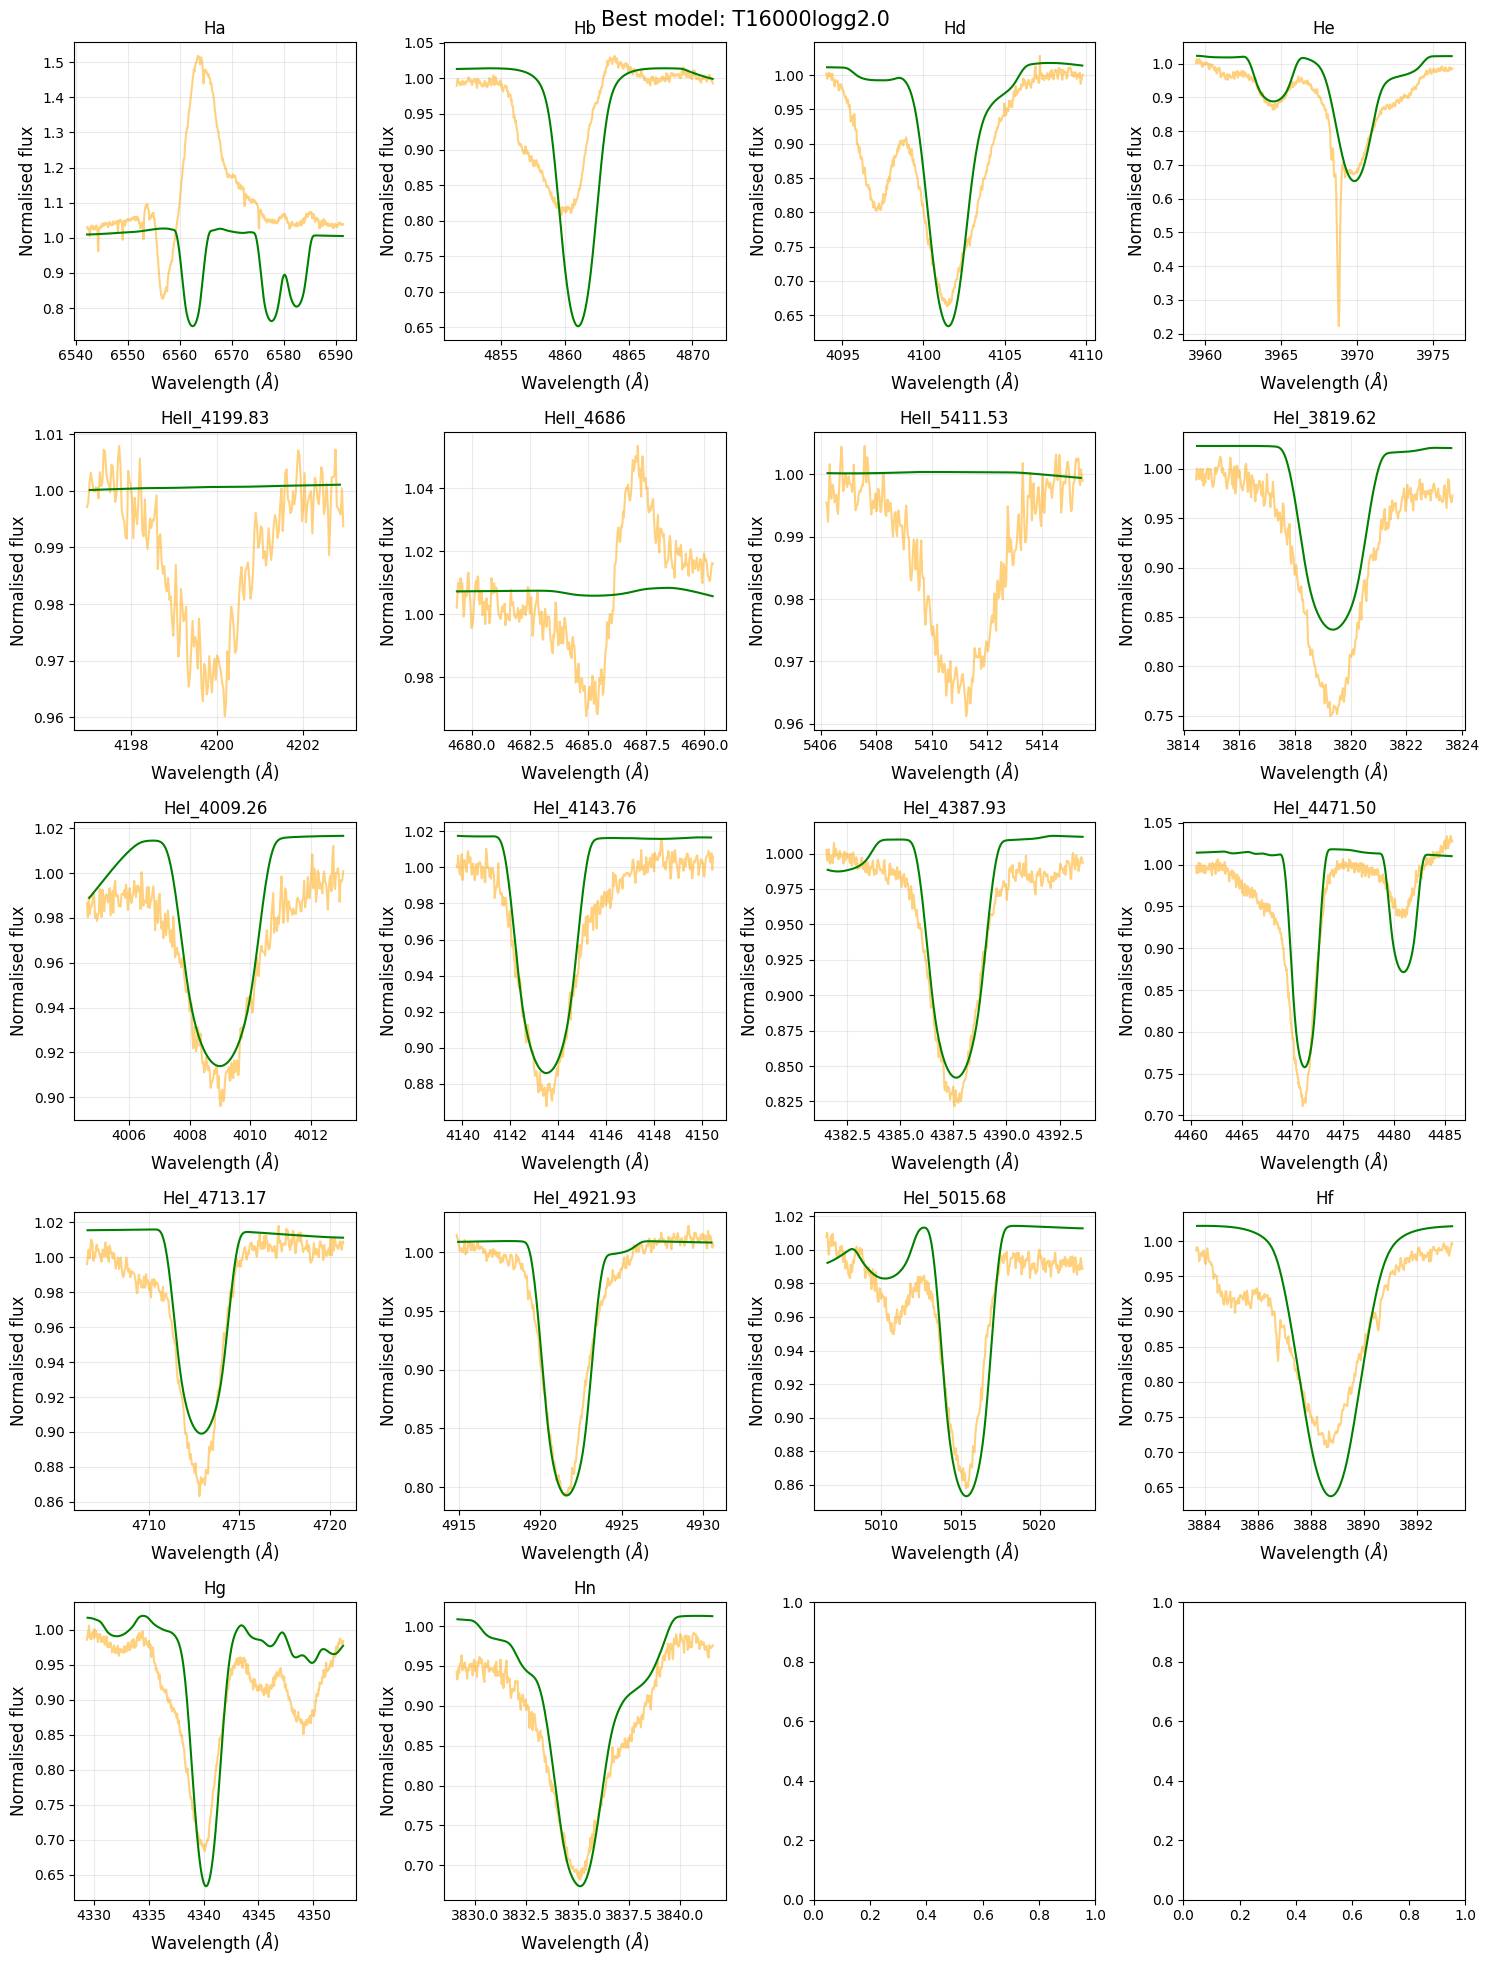

In [8]:
plot_best_model(spectra, models, lines_path, min(chi2, key=chi2.get), vrad, vsini_best, 
                save=(save_path + f'({today})BestModel.png'))

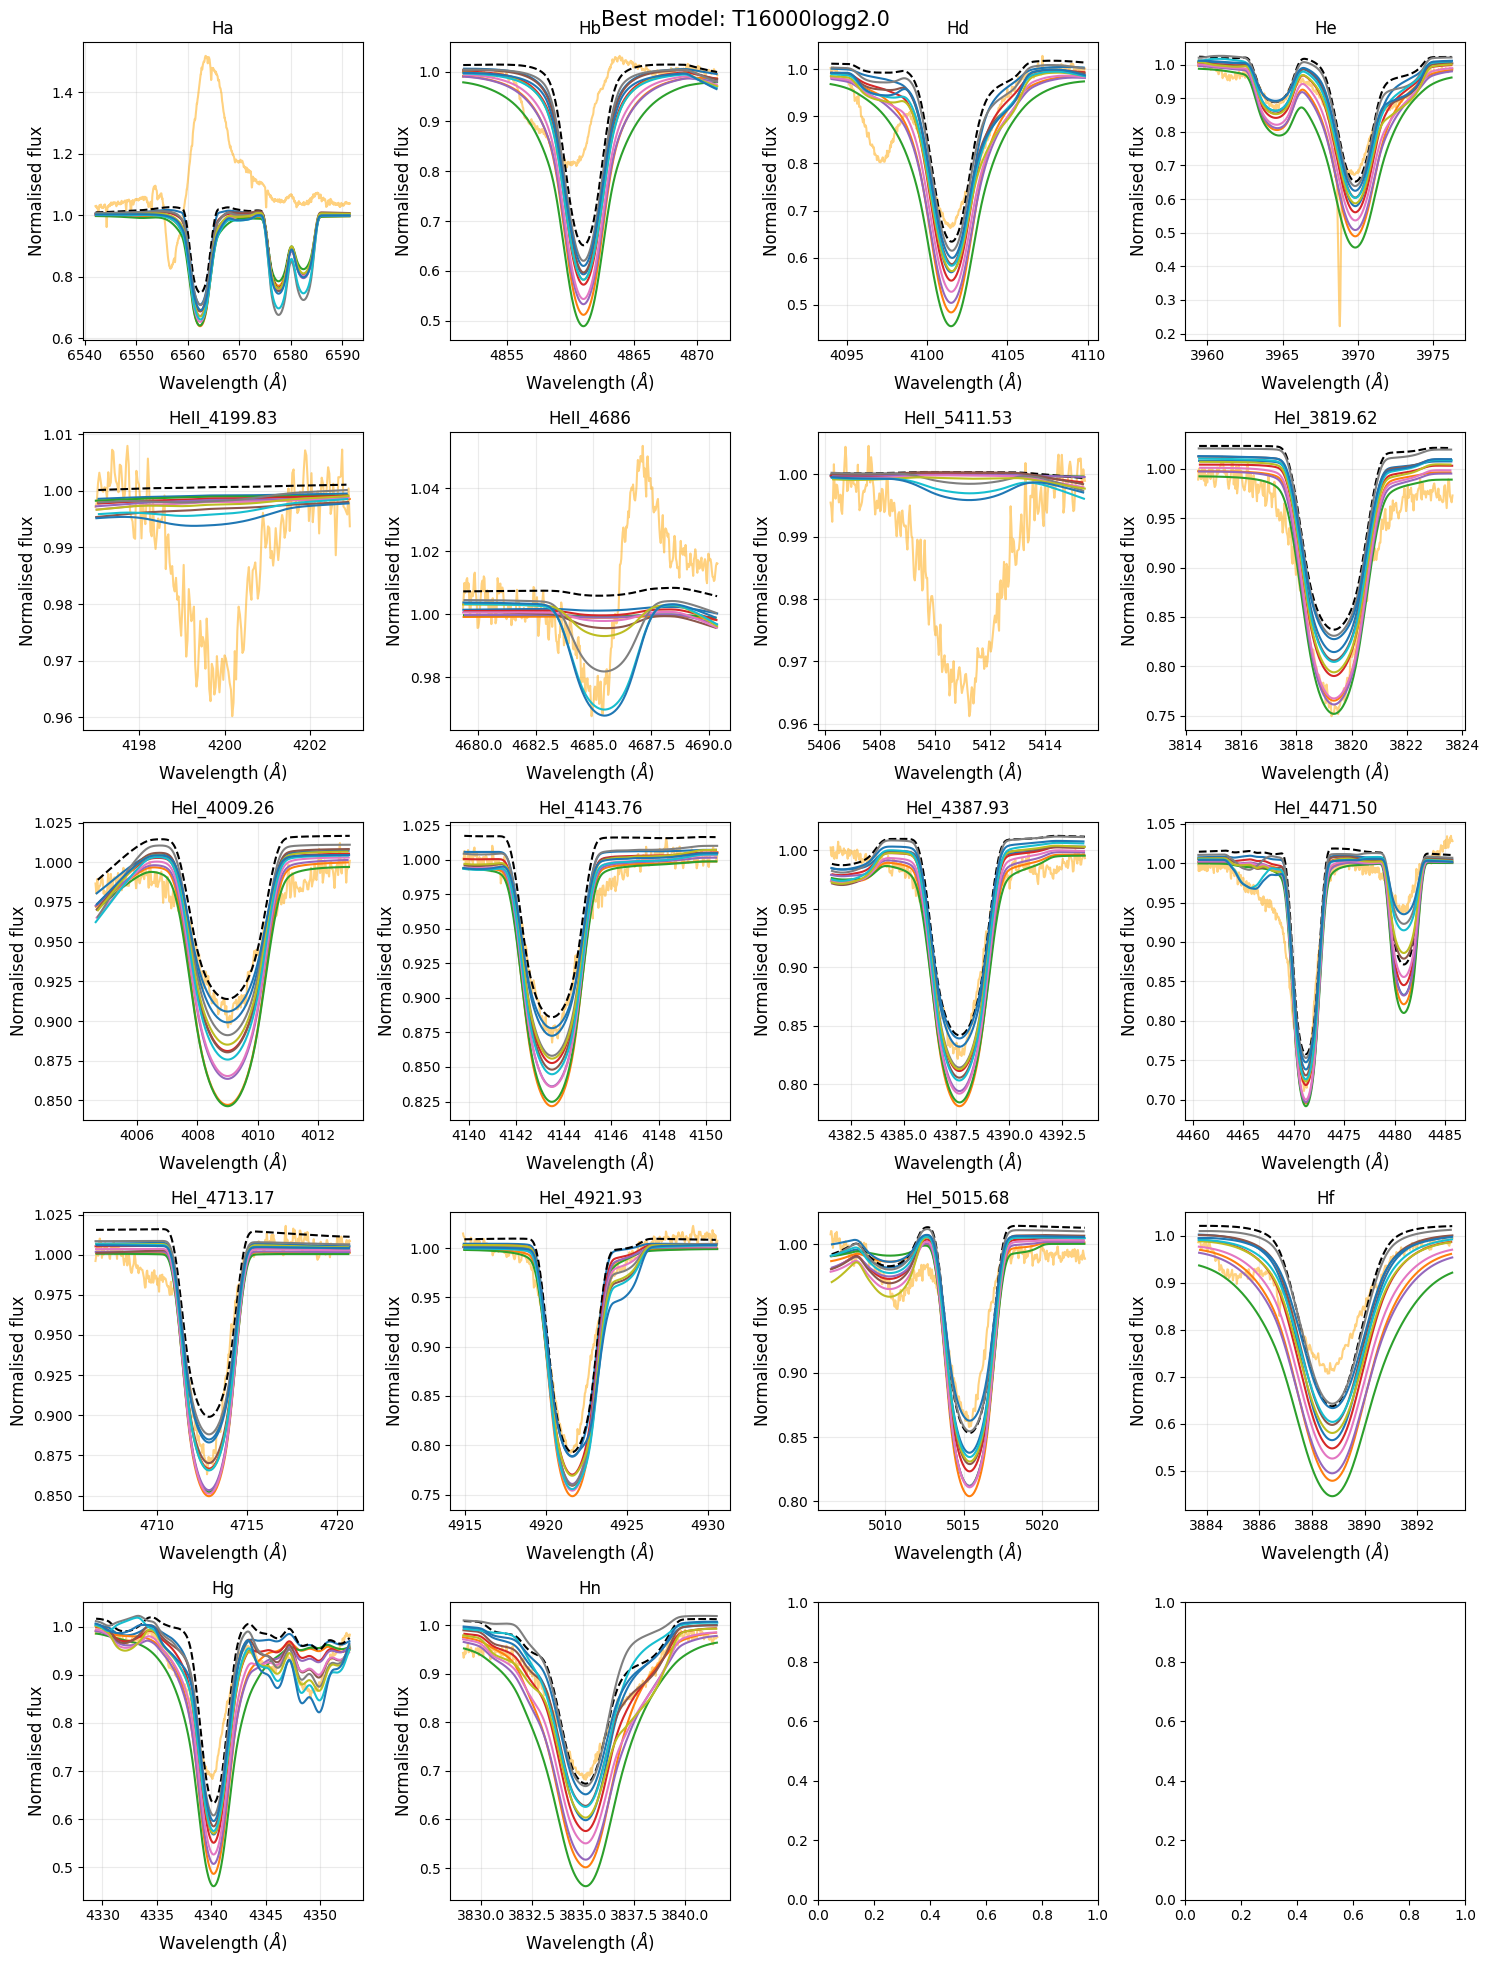

In [10]:
selection = models_in_interval(models, T1=10000, T2=20000, log_g1=1.0, log_g2=2.5)
plot_models_over_lines(spectra, selection, lines_path, vrad, vsini_best, best_model=min(chi2, key=chi2.get),
                       save=(save_path + f'({today})AllModels.png'))